# 3. 色彩空间与颜色处理

**目标**：能按颜色维度处理图像，为分割、增强打基础。

在上一章中，我们处理图像时主要关注**像素的位置**（空间变换）和**像素的灰度值**（像素域滤波）。
但现实世界是彩色的，彩色图像包含的信息远不止亮度——还有**色相、饱和度、色调**。

本章要做的事情可以概括为一句话：**把图像从「像素值数组」转换成「颜色描述」，从而利用颜色信息做分割、增强和校正**。

这两类操作贯穿了几乎所有传统图像处理任务：车牌识别、肤色检测、背景替换、图像增强、颜色校正，都建立在它们之上。本章会先把每一类操作的**原理**讲清楚，再用 OpenCV 函数验证。

> **代码独立性说明**：本章每个代码块都**完全自包含**——自己导入库、自己读取图像（或自建测试数据），不依赖其他任何小节。每个代码块都可以单独运行。

## 3.0 术语与变量名约定（先读这一段）

本章会频繁出现 **HSV、YCrCb、Lab** 这些**色彩空间术语**。为了避免「术语」和「代码变量」混淆，本章统一约定：

| 色彩空间术语 | 代码里的图像变量 | 说明 |
|--------------|------------------|------|
| BGR | `img_bgr` | OpenCV 默认读入的图像 |
| RGB | `img_rgb` | 显示用的图像 |
| Gray | `img_gray` | 灰度图 |
| HSV | `img_hsv` | HSV 空间的图像数组 |
| YCrCb | `img_ycrcb` | YCrCb 空间的图像数组 |
| Lab | `img_lab` | Lab 空间的图像数组 |

**两条硬规则**：

1. **不要把 `hsv`、`ycrcb`、`lab` 当变量名**——它们是色彩空间术语，直接当变量名会让读者分不清「这是在说空间，还是在说某个数组」。统一用 `img_hsv`、`img_ycrcb`、`img_lab`。
2. **`img_hsv` 只是一个普通的 NumPy 数组**，形状与 `img_bgr` 相同，只是三个通道的数值含义变成了 H、S、V。它不是特殊类型，OpenCV 也不会因为变量名叫 `img_hsv` 就自动按 HSV 处理。

## 3.0.1 `cv2.inRange` 的通用语义（重要）

`cv2.inRange(src, lowerb, upperb)` 对 `src` **逐通道**做数值区间判断，返回 8 位掩码：

- 对每个像素的每个通道，判断是否满足 `lowerb[c] <= src[y, x, c] <= upperb[c]`；
- 所有通道**同时**满足 → 掩码该位置写 `255`；
- 否则 → 写 `0`。

**关键点**：`cv2.inRange` **不识别色彩空间**。它不知道你传进来的是 BGR、HSV、YCrCb 还是 Lab，它只做数值比较。你传什么空间的图像，`lowerb` / `upperb` 就要按那个空间的通道含义来给。

**四种空间都成立**（区间变量统一用 `lowerb` / `upperb`，不带任何色彩空间暗示）：

```python
# 传 HSV 图像：三个区间依次对应 H、S、V
mask = cv2.inRange(img_hsv, lowerb, upperb)

# 传 YCrCb 图像：三个区间依次对应 Y、Cr、Cb
mask = cv2.inRange(img_ycrcb, lowerb, upperb)

# 传 Lab 图像：三个区间依次对应 L、a、b
mask = cv2.inRange(img_lab, lowerb, upperb)

# 传灰度图：区间是单通道的亮度，lowerb / upperb 是标量
mask = cv2.inRange(img_gray, lowerb, upperb)
```

**为什么例子里常用 HSV**：因为 HSV 里 H 单独表示色相、与亮度无关，颜色分割效果最好。**这不是 `inRange` 的要求，只是 HSV 更适合颜色分割。**

主要内容：
1. BGR / RGB 通道顺序与拆分合并
2. BGR ↔ 灰度转换
3. HSV 色彩空间
4. YCrCb 色彩空间
5. Lab 色彩空间
6. 色彩空间选型
7. 颜色范围选取与 inRange
8. 灰度图伪彩色
9. 伪彩色图像合成
10. 色彩风格滤镜与调节
11. 颜色分割完整流程
12. 肤色检测完整流程
13. 白平衡基础
14. 颜色迁移基础
15. 常见坑与附录

---
## 3.1 BGR / RGB：通道顺序、数组形状、通道拆分与合并、BGR↔RGB 转换

在上一章中，我们处理图像时，经常说“图像就是一个 NumPy 数组”。对于彩色图像，这个数组是**三维**的：`(height, width, channels)`。

但有一个**非常容易踩坑**的细节：**OpenCV 默认读取的图像是 BGR 顺序，而不是 RGB**。

这意味着：

- 当你用 `cv2.imread` 读取一张彩色图时，通道顺序是 **蓝、绿、红**；
- 当你用 `matplotlib.pyplot.imshow` 显示时，它期望的是 **红、绿、蓝**；
- 如果你直接把 OpenCV 读的图传给 Matplotlib，颜色就会**红蓝互换**。

本节要讲清楚：

1. 为什么 OpenCV 用 BGR；
2. 如何查看和操作通道；
3. 如何正确地在 BGR 和 RGB 之间转换；
4. 通道拆分与合并的用法。

**本节的结构安排**：

1. 先讲**通道顺序**——为什么会有 BGR 和 RGB 两种；
2. 再讲**数组形状**——怎么查看通道数、怎么索引通道；
3. 最后讲**拆分与合并**——`split` / `merge` 和 BGR↔RGB 转换。

### 3.1.1 为什么 OpenCV 用 BGR

历史原因：OpenCV 早期（2000 年左右）与某些相机厂商和图像采集卡合作，这些硬件的默认输出格式就是 BGR。为了兼容，OpenCV 沿用了 BGR 作为默认通道顺序。

**这不是 bug，是历史遗留的设计选择。** 你只需要记住：

- `cv2.imread` → BGR；
- `cv2.imshow` → 期望 BGR；
- `cv2.imwrite` → 期望 BGR；
- `matplotlib.pyplot.imshow` → 期望 RGB；
- `PIL.Image` → 期望 RGB。

**显示时红蓝互换，就是因为把 BGR 直接传给了期望 RGB 的显示函数。**

### 3.1.2 数组形状与通道索引

彩色图像的 NumPy 数组形状是 `(height, width, channels)`：

- `img.shape[0]` → 高度（行数）；
- `img.shape[1]` → 宽度（列数）；
- `img.shape[2]` → 通道数（通常为 3）。

访问某个通道：

- `img[:, :, 0]` → 第 0 通道（BGR 中就是蓝色通道）；
- `img[:, :, 1]` → 第 1 通道（绿色）；
- `img[:, :, 2]` → 第 2 通道（红色）。

**注意**：OpenCV 的通道索引是 `[y, x, c]`，而不是 `[x, y, c]`。

### 3.1.3 通道拆分与合并、BGR↔RGB 转换

`cv2.split(img)`：把多通道图像拆成单通道数组的列表；
`cv2.merge([ch1, ch2, ch3])`：把多个单通道数组合并成多通道图像。

BGR↔RGB 转换：

```python
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
```

或者手动交换通道：

```python
b, g, r = cv2.split(img_bgr)
img_rgb = cv2.merge([r, g, b])
```

**注意**：`cv2.cvtColor` 是**必须经过 BGR 中转**的——不能直接从 HSV 转 Lab，必须先转回 BGR 再转目标空间。

图像形状 (h, w, c): (414, 500, 3)
通道数: 3


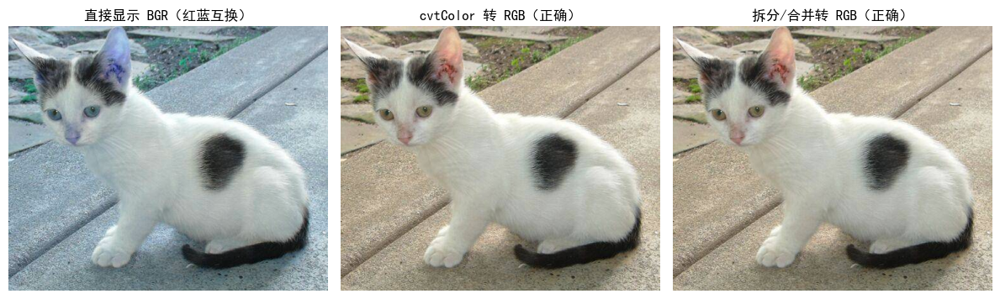

结论：
  OpenCV 读入为 BGR，Matplotlib 期望 RGB
  直接显示 BGR -> 红蓝互换
  用 cvtColor 或拆分/合并转 RGB -> 颜色正确


In [20]:
# ============ 3.1 实例：BGR/RGB 通道操作与显示差异 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

print('图像形状 (h, w, c):', img_bgr.shape)                                        # 打印形状
print('通道数:', img_bgr.shape[2])                                                  # 打印通道数

# 直接传给 Matplotlib：红蓝互换
plt.figure(figsize=(12, 5))                                                         # 画布

plt.subplot(1, 3, 1)                                                                # 直接显示 BGR
plt.imshow(img_bgr)                                                                 # 显示
plt.title('直接显示 BGR（红蓝互换）')                                               # 标题
plt.axis('off')                                                                     # 关闭坐标轴

# 转换为 RGB 后显示
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)                                  # BGR -> RGB

plt.subplot(1, 3, 2)                                                                # 转换为 RGB
plt.imshow(img_rgb)                                                                 # 显示
plt.title('cvtColor 转 RGB（正确）')                                                # 标题
plt.axis('off')                                                                     # 关闭坐标轴

# 手动拆分与合并
b, g, r = cv2.split(img_bgr)                                                        # 拆分通道
img_rgb_manual = cv2.merge([r, g, b])                                               # 手动合并为 RGB

plt.subplot(1, 3, 3)                                                                # 手动 RGB
plt.imshow(img_rgb_manual)                                                          # 显示
plt.title('拆分/合并转 RGB（正确）')                                                # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：')                                                                     # 打印结论
print('  OpenCV 读入为 BGR，Matplotlib 期望 RGB')                                    # 结论第一行
print('  直接显示 BGR -> 红蓝互换')                                                  # 结论第二行
print('  用 cvtColor 或拆分/合并转 RGB -> 颜色正确')                                 # 结论第三行

---
## 3.2 BGR ↔ 灰度转换

灰度图只有一个通道，处理速度快、存储小，而且很多任务（如边缘检测、形状分析）不需要颜色信息。

**转换公式**：

$$
Y = 0.299 \cdot R + 0.587 \cdot G + 0.114 \cdot B
$$

**为什么是这三个系数**：因为人眼对绿色最敏感、红色次之、蓝色最不敏感。加权平均符合人眼对亮度的感知。

**OpenCV 函数**：

```python
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
```

官方与手动最大差异: 1


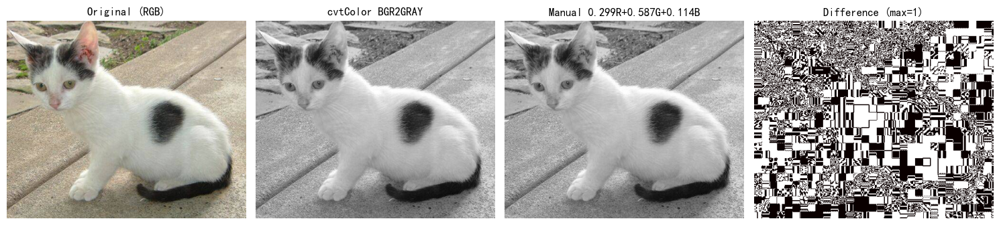

In [21]:
# ============ 3.2 实例：BGR -> Gray 与手动加权对比 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 官方转换
img_gray_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)                             # OpenCV 灰度

# 手动加权（注意 BGR 顺序）
b, g, r = cv2.split(img_bgr.astype(np.float32))                                     # 拆分并转 float
img_gray_manual = 0.299 * r + 0.587 * g + 0.114 * b                                 # 加权公式
img_gray_manual = np.clip(img_gray_manual, 0, 255).astype(np.uint8)                 # 截断并转 uint8

# 计算差异
diff = cv2.absdiff(img_gray_cv, img_gray_manual)                                    # 绝对差
print('官方与手动最大差异:', diff.max())                                            # 打印最大差异

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original (RGB)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # OpenCV 灰度
plt.imshow(img_gray_cv, cmap='gray')                                                # 显示
plt.title('cvtColor BGR2GRAY')                                                      # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # 手动灰度
plt.imshow(img_gray_manual, cmap='gray')                                            # 显示
plt.title('Manual 0.299R+0.587G+0.114B')                                            # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # 差异
plt.imshow(diff, cmap='hot')                                                        # 显示
plt.title(f'Difference (max={diff.max()})')                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

---
## 3.3 HSV 色彩空间

HSV 是**色相（hue）、饱和度（saturation）、明度（value）** 的缩写。

**为什么需要 HSV**：在 RGB 空间中，颜色和亮度是耦合的——改变亮度会改变 RGB 三个通道的值。但在 HSV 中：

- **H（色相）**：颜色的种类（红、绿、蓝……），与亮度无关；
- **S（饱和度）**：颜色的纯度；
- **V（明度）**：颜色的明暗。

这使得 HSV 在**颜色分割（color segmentation）**时非常有用：你只需要指定 H 的范围，就能提取某种颜色，而不用担心光照变化。

> **术语与变量名提醒**：本节中「HSV」是色彩空间的名称；代码里保存 HSV 图像的变量统一叫 `img_hsv`。`img_hsv` 只是一个普通的 NumPy 数组，形状与 `img_bgr` 相同，只是三个通道的数值含义变成了 H、S、V。

### 3.3.1 HSV 的物理含义与 OpenCV 取值范围

**物理含义**：

- **H**：角度，0° 是红色，120° 是绿色，240° 是蓝色；
- **S**：0 是灰色，1 是纯色；
- **V**：0 是黑色，1 是白色。

**OpenCV 的取值范围**（注意：与标准 HSV 不同）：

| 通道 | 范围 |
|------|------|
| H | 0 ~ 179 |
| S | 0 ~ 255 |
| V | 0 ~ 255 |

**为什么 H 是 0~179 而不是 0~360**：因为 OpenCV 用 `uint8` 存储 H，8 位最大是 255。为了把 360° 映射到 0~179，OpenCV 把角度**除以 2**。所以：

- 0° → 0
- 120° → 60
- 240° → 120
- 360° → 180（实际取 179）

**H 的环形特性**：

- H 是环形的，0 和 179 是相邻的（都是红色）；
- 红色跨越 0 和 179 两端，所以提取红色需要**两段阈值**；
- 不能只用一段区间提取全部红色，必须再加一段覆盖 170~179。

### 3.3.2 RGB → HSV 的转换公式（原理补充）

前面的小节讲了 HSV 的物理含义和取值范围，但**没有解释 H、S、V 三个分量到底是怎么从 R、G、B 算出来的**。这里把公式补上。

**前提**：先把 R、G、B 归一化到 $[0, 1]$。记：

$$
C_{max} = \max(R, G, B), \quad
C_{min} = \min(R, G, B), \quad
\Delta = C_{max} - C_{min}
$$

**V（明度）**：直接取三通道的最大值：

$$
V = C_{max}
$$

**S（饱和度）**：描述颜色的纯度，用最大最小之差除以最大值：

$$
S =
\begin{cases}
0, & C_{max} = 0 \\
\dfrac{\Delta}{C_{max}}, & C_{max} \neq 0
\end{cases}
$$

**H（色相）**：根据哪个通道最大分情况，最后归一到 $[0, 360°)$：

$$
H =
\begin{cases}
0, & \Delta = 0 \\
60° \times \left(\dfrac{G - B}{\Delta} \bmod 6\right), & C_{max} = R \\
60° \times \left(\dfrac{B - R}{\Delta} + 2\right), & C_{max} = G \\
60° \times \left(\dfrac{R - G}{\Delta} + 4\right), & C_{max} = B
\end{cases}
$$

**直观理解**：

- $\Delta = 0$ 表示三通道相等，即灰色，此时没有色相，H 定义为 0；
- 当 R 最大时，色相在红区（0° 附近），由 G、B 的差决定偏黄还是偏品红；
- 当 G 最大时，色相在绿区（120° 附近），公式加 2 段；
- 当 B 最大时，色相在蓝区（240° 附近），公式加 4 段；
- 乘 60° 是因为 6 个扇区把 360° 均分。

**OpenCV 的存储映射**：

- $H_{opencv} = H / 2 \in [0, 179]$（uint8，见 3.3.1 节）；
- $S_{opencv} = S \times 255 \in [0, 255]$；
- $V_{opencv} = V \times 255 \in [0, 255]$。

**注意**：`cv2.cvtColor` 内部用的就是这套公式（具体实现略有数值优化），下面的代码可以手动复现它并与官方结果对比。

### 3.3.3 HSV_FULL：更精确的变体

OpenCV 还提供了 `COLOR_BGR2HSV_FULL`，它把 H 映射到 **0~255**，精度更高。

- `COLOR_BGR2HSV`：H ∈ [0, 179]，常用；
- `COLOR_BGR2HSV_FULL`：H ∈ [0, 255]，精度更高，但阈值范围也要相应调整。

**注意**：`HSV_FULL` 的阈值**不能直接套用**普通 HSV 的阈值。

HSV 图像形状: (414, 500, 3)
H 范围: 0 ~ 179
S 范围: 0 ~ 255
V 范围: 3 ~ 255


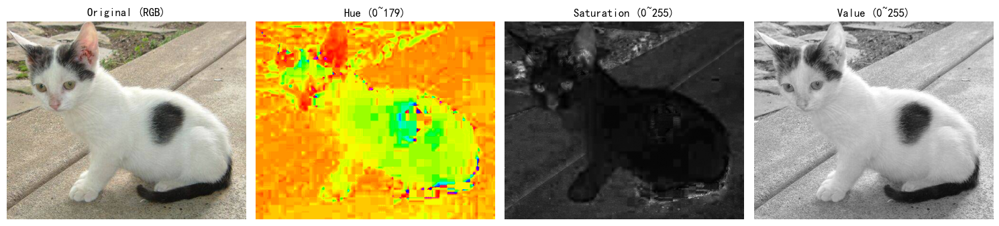

结论：
  H 表示色相，与亮度无关，适合颜色分割
  S 表示饱和度，V 表示明度
  H 的范围是 0~179，不是 0~360
  img_hsv 只是普通 NumPy 数组，不是特殊类型


In [22]:
# ============ 3.3 实例：BGR -> HSV 与通道可视化 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 转 HSV：变量名叫 img_hsv，明确表示「这是一张 HSV 空间的图像」
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)                                  # BGR -> HSV

# 拆分通道
h, s, v = cv2.split(img_hsv)                                                        # 拆分

print('HSV 图像形状:', img_hsv.shape)                                               # 打印形状
print('H 范围:', h.min(), '~', h.max())                                             # 打印 H 范围
print('S 范围:', s.min(), '~', s.max())                                             # 打印 S 范围
print('V 范围:', v.min(), '~', v.max())                                             # 打印 V 范围

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original (RGB)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # H 通道
plt.imshow(h, cmap='hsv')                                                           # 显示
plt.title('Hue (0~179)')                                                            # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # S 通道
plt.imshow(s, cmap='gray')                                                          # 显示
plt.title('Saturation (0~255)')                                                     # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # V 通道
plt.imshow(v, cmap='gray')                                                          # 显示
plt.title('Value (0~255)')                                                          # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：')                                                                     # 打印结论
print('  H 表示色相，与亮度无关，适合颜色分割')                                      # 结论第一行
print('  S 表示饱和度，V 表示明度')                                                  # 结论第二行
print('  H 的范围是 0~179，不是 0~360')                                              # 结论第三行
print('  img_hsv 只是普通 NumPy 数组，不是特殊类型')                                 # 结论第四行

H 最大差异（考虑环形）: 0.5000458
S 最大差异: 0.50481415
V 最大差异: 0.0
说明：差异主要来自 uint8 量化舍入，公式本身与 OpenCV 一致


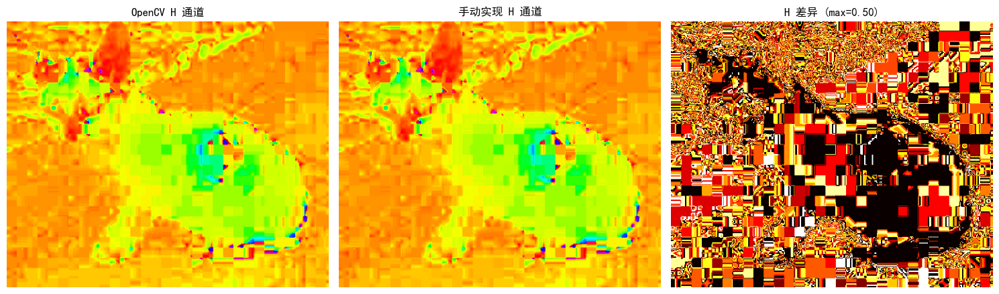

结论：手动 RGB->HSV 公式与 cv2.cvtColor 结果一致，验证了公式的正确性


In [23]:
# ============ 3.3.4 实例：手动实现 RGB -> HSV 并与 OpenCV 对比 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 1. 先转成 RGB 并归一化到 [0, 1]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0       # RGB 归一化
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]                      # 拆分 R/G/B

# 2. 计算 Cmax / Cmin / Delta
Cmax = np.max(img_rgb, axis=2)                                                      # 最大通道
Cmin = np.min(img_rgb, axis=2)                                                      # 最小通道
Delta = Cmax - Cmin                                                                 # 差值

# 3. V = Cmax
V = Cmax                                                                            # 明度

# 4. S = Delta / Cmax（Cmax=0 时为 0）
S = np.zeros_like(Cmax)                                                             # 初始化 S
non_zero = Cmax != 0                                                                # 非零掩码
S[non_zero] = Delta[non_zero] / Cmax[non_zero]                                      # 计算 S

# 5. H 分情况计算（结果单位为度，范围 [0, 360)）
H = np.zeros_like(Cmax)                                                             # 初始化 H
delta_zero = (Delta == 0)                                                           # Delta 为 0 的掩码

# 情况 B：Cmax = R
mask_r = (Cmax == R) & (~delta_zero)                                                # R 最大
H[mask_r] = 60.0 * (((G[mask_r] - B[mask_r]) / Delta[mask_r]) % 6)                  # 红区公式

# 情况 C：Cmax = G
mask_g = (Cmax == G) & (~delta_zero)                                                # G 最大
H[mask_g] = 60.0 * ((B[mask_g] - R[mask_g]) / Delta[mask_g] + 2)                    # 绿区公式

# 情况 D：Cmax = B
mask_b = (Cmax == B) & (~delta_zero)                                                # B 最大
H[mask_b] = 60.0 * ((R[mask_b] - G[mask_b]) / Delta[mask_b] + 4)                    # 蓝区公式

H = np.mod(H, 360.0)                                                                # 归一到 [0, 360)

# 6. 按 OpenCV 存储方式映射：H/2 -> [0,179]，S*255，V*255
H_cv = np.clip(H / 2.0, 0, 179)                                                     # H 映射
S_cv = np.clip(S * 255.0, 0, 255)                                                   # S 映射
V_cv = np.clip(V * 255.0, 0, 255)                                                   # V 映射

# 7. 与 OpenCV 官方结果对比
img_hsv_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)            # 官方 HSV
h_cv, s_cv, v_cv = cv2.split(img_hsv_cv)                                            # 拆分

h_diff = np.abs(h_cv - H_cv)                                                        # H 差异
h_diff = np.minimum(h_diff, 180 - h_diff)                                           # 考虑 H 环形
s_diff = np.abs(s_cv - S_cv)                                                        # S 差异
v_diff = np.abs(v_cv - V_cv)                                                        # V 差异

print('H 最大差异（考虑环形）:', h_diff.max())                                      # 打印 H 最大差
print('S 最大差异:', s_diff.max())                                                  # 打印 S 最大差
print('V 最大差异:', v_diff.max())                                                  # 打印 V 最大差
print('说明：差异主要来自 uint8 量化舍入，公式本身与 OpenCV 一致')                  # 说明

# 8. 可视化
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 3, 1)                                                                # 官方 H
plt.imshow(h_cv.astype(np.uint8), cmap='hsv')                                       # 显示
plt.title('OpenCV H 通道')                                                          # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 3, 2)                                                                # 手动 H
plt.imshow(H_cv.astype(np.uint8), cmap='hsv')                                       # 显示
plt.title('手动实现 H 通道')                                                        # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 3, 3)                                                                # 差异
plt.imshow(h_diff, cmap='hot')                                                      # 显示
plt.title(f'H 差异 (max={h_diff.max():.2f})')                                       # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：手动 RGB->HSV 公式与 cv2.cvtColor 结果一致，验证了公式的正确性')       # 打印结论

---
## 3.4 YCrCb 色彩空间

YCrCb 是**亮度（Y）+ 色度（chrominance，Cr、Cb）** 的色彩空间，广泛应用于视频编码（如 JPEG、MPEG）和肤色检测。

**通道含义**：

- **Y**：亮度（Luminance）；
- **Cr**：红色色度（Chrominance-Red）；
- **Cb**：蓝色色度（Chrominance-Blue）。

**OpenCV 取值范围**：

| 通道 | 范围 |
|------|------|
| Y | 0 ~ 255 |
| Cr | 0 ~ 255 |
| Cb | 0 ~ 255 |

**与 YUV 的关系**：YCrCb 是 YUV 的一种缩放版本，方便用 8 位存储。

> **术语与变量名提醒**：YCrCb 是色彩空间的名称；代码中保存该空间图像的变量统一叫 `img_ycrcb`。

### 3.4.1 RGB → YCrCb 的转换公式（原理补充）

与灰度一样，YCrCb 也是把亮度 Y 单独拿出来，另外两个通道 Cr、Cb 只表示色度。

**标准（ITU-R BT.601）公式**（R、G、B 归一化到 $[0, 1]$）：

$$
\begin{aligned}
Y  &= 0.299 R + 0.587 G + 0.114 B \\
Cr &= (R - Y) \times 0.713 + 0.5 \\
Cb &= (B - Y) \times 0.564 + 0.5
\end{aligned}
$$

**OpenCV 存储映射**：

- $Y_{opencv} = Y \times 255 \in [0, 255]$；
- $Cr_{opencv} = Cr \times 255 \in [0, 255]$；
- $Cb_{opencv} = Cb \times 255 \in [0, 255]$。

**直观理解**：

- Y 的系数与灰度公式完全相同，说明 Y 就是感知亮度；
- Cr 衡量「偏红程度」，R 比 Y 大时 Cr 偏大（偏红），R 比 Y 小时 Cr 偏小（偏青）；
- Cb 衡量「偏蓝程度」，B 比 Y 大时 Cb 偏大（偏蓝），B 比 Y 小时 Cb 偏小（偏黄）；
- 加 0.5 是为了把范围平移到 $[0, 1]$，方便存储为正数。

**为什么肤色检测用 YCrCb**：肤色在 Cr、Cb 两个色度维度上分布集中，且与亮度 Y 基本无关。所以经典阈值 `133 < Cr < 173, 77 < Cb < 127` 在不同光照、不同人种下都比较稳定。

### 3.4.2 经典肤色阈值

在 YCrCb 空间中，**肤色（skin color）**有一个相对稳定的范围：

$$
133 \leq Cr \leq 173, \quad 77 \leq Cb \leq 127
$$

这个范围对**不同人种、不同光照**都有较好的鲁棒性，是肤色检测（skin detection）的经典方法。

**注意**：这里的「肤色」指的是**人体皮肤**，不是猫、狗等动物的毛发颜色。用下面 3.12 节的例子时，要输入含人体皮肤的图片（如 `imgLena.tif`），而不是 `cat.jpg`。

YCrCb 图像形状: (414, 500, 3)
Y 范围: 1 ~ 255
Cr 范围: 115 ~ 171
Cb 范围: 67 ~ 135


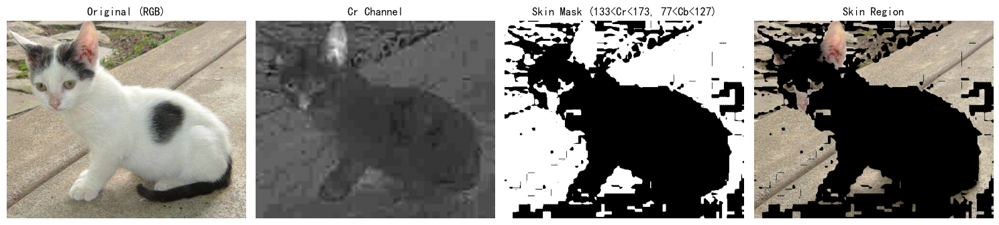

结论：YCrCb 的 Cr/Cb 通道对肤色有较好的区分度
注意：本例用 cat.jpg 仅演示 Cr/Cb 通道的数值分布
      真正的肤色检测请用含人体皮肤的图片，见 3.12 节


In [24]:
# ============ 3.4 实例：BGR -> YCrCb 与肤色阈值 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 转 YCrCb：变量名叫 img_ycrcb
img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)                              # BGR -> YCrCb

# 拆分通道
y, cr, cb = cv2.split(img_ycrcb)                                                    # 拆分

print('YCrCb 图像形状:', img_ycrcb.shape)                                           # 打印形状
print('Y 范围:', y.min(), '~', y.max())                                             # 打印 Y 范围
print('Cr 范围:', cr.min(), '~', cr.max())                                          # 打印 Cr 范围
print('Cb 范围:', cb.min(), '~', cb.max())                                          # 打印 Cb 范围

# 肤色阈值：注意 inRange 不识别色彩空间，它只对 img_ycrcb 逐通道做区间判断
lowerb = np.array([0, 133, 77])                                                     # 下界 (Y, Cr, Cb)
upperb = np.array([255, 173, 127])                                                  # 上界 (Y, Cr, Cb)
skin_mask = cv2.inRange(img_ycrcb, lowerb, upperb)                                  # 肤色掩码

# 用掩码提取肤色区域
skin = cv2.bitwise_and(img_bgr, img_bgr, mask=skin_mask)                            # 提取肤色

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original (RGB)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # Cr 通道
plt.imshow(cr, cmap='gray')                                                         # 显示
plt.title('Cr Channel')                                                             # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # 肤色掩码
plt.imshow(skin_mask, cmap='gray')                                                  # 显示
plt.title('Skin Mask (133<Cr<173, 77<Cb<127)')                                      # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # 肤色区域
plt.imshow(cv2.cvtColor(skin, cv2.COLOR_BGR2RGB))                                   # 显示
plt.title('Skin Region')                                                            # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：YCrCb 的 Cr/Cb 通道对肤色有较好的区分度')                              # 打印结论
print('注意：本例用 cat.jpg 仅演示 Cr/Cb 通道的数值分布')                            # 提醒
print('      真正的肤色检测请用含人体皮肤的图片，见 3.12 节')                        # 提醒

Y 最大差异: 0.49899292
Cr 最大差异: 1.2796555
Cb 最大差异: 1.175148
说明：差异主要来自 uint8 量化舍入，公式本身与 OpenCV 一致


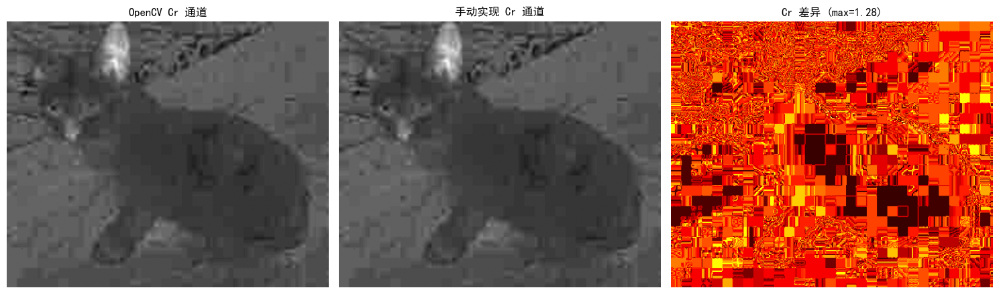

结论：手动 RGB->YCrCb 公式与 cv2.cvtColor 结果一致，验证了公式的正确性


In [25]:
# ============ 3.4.3 实例：手动实现 RGB -> YCrCb 并与 OpenCV 对比 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 1. 转 RGB 并归一化到 [0, 1]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0       # RGB 归一化
R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]                      # 拆分 R/G/B

# 2. 计算 Y / Cr / Cb（BT.601）
Y = 0.299 * R + 0.587 * G + 0.114 * B                                               # 亮度 Y
Cr = (R - Y) * 0.713 + 0.5                                                          # 红色色度
Cb = (B - Y) * 0.564 + 0.5                                                          # 蓝色色度

# 3. 映射到 OpenCV 的 uint8 范围
Y_cv = np.clip(Y * 255.0, 0, 255)                                                   # Y -> [0,255]
Cr_cv = np.clip(Cr * 255.0, 0, 255)                                                 # Cr -> [0,255]
Cb_cv = np.clip(Cb * 255.0, 0, 255)                                                 # Cb -> [0,255]

# 4. 与 OpenCV 官方结果对比
img_ycrcb_cv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb).astype(np.float32)        # 官方 YCrCb
y_cv, cr_cv, cb_cv = cv2.split(img_ycrcb_cv)                                        # 拆分

y_diff = np.abs(y_cv - Y_cv)                                                        # Y 差异
cr_diff = np.abs(cr_cv - Cr_cv)                                                     # Cr 差异
cb_diff = np.abs(cb_cv - Cb_cv)                                                     # Cb 差异

print('Y 最大差异:', y_diff.max())                                                  # 打印 Y 最大差
print('Cr 最大差异:', cr_diff.max())                                                # 打印 Cr 最大差
print('Cb 最大差异:', cb_diff.max())                                                # 打印 Cb 最大差
print('说明：差异主要来自 uint8 量化舍入，公式本身与 OpenCV 一致')                  # 说明

# 5. 可视化
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 3, 1)                                                                # 官方 Cr
plt.imshow(cr_cv.astype(np.uint8), cmap='gray')                                     # 显示
plt.title('OpenCV Cr 通道')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 3, 2)                                                                # 手动 Cr
plt.imshow(Cr_cv.astype(np.uint8), cmap='gray')                                     # 显示
plt.title('手动实现 Cr 通道')                                                       # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 3, 3)                                                                # 差异
plt.imshow(cr_diff, cmap='hot')                                                     # 显示
plt.title(f'Cr 差异 (max={cr_diff.max():.2f})')                                     # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：手动 RGB->YCrCb 公式与 cv2.cvtColor 结果一致，验证了公式的正确性')     # 打印结论

---
## 3.5 Lab 色彩空间

Lab 是**感知均匀（perceptually uniform）**的色彩空间，由国际照明委员会（CIE）定义。

**通道含义**：

- **L**：亮度（Lightness），0 是黑，100 是白；
- **a**：绿-红轴，负值是绿，正值是红；
- **b**：蓝-黄轴，负值是蓝，正值是黄。

**OpenCV 取值范围**（8 位）：

| 通道 | 范围 |
|------|------|
| L | 0 ~ 255 |
| a | 0 ~ 255 |
| b | 0 ~ 255 |

**为什么 Lab 重要**：

- **感知均匀**：Lab 中两个颜色的欧氏距离，与人眼感知的差异成正比；
- **颜色差异度量**：可以用 ΔE 计算两个颜色的感知差异；
- **L 通道光照归一化**：只取 L 通道可以消除光照影响。

**应用**：颜色校正（color correction）、颜色迁移（color transfer）、色彩风格滤镜。

> **术语与变量名提醒**：Lab 是色彩空间的名称；代码中保存该空间图像的变量统一叫 `img_lab`。

### RGB → Lab 的转换思路

Lab 的完整推导涉及 CIE XYZ 中间空间，比 HSV、YCrCb 复杂。这里给出**思路和关键公式**，不作为必须手写的实现。
**第一步：RGB → XYZ**（需要先做 sRGB 反伽马校正，再乘变换矩阵）：
$$
\begin{bmatrix} X \\ Y \\ Z \end{bmatrix}
=
\begin{bmatrix}
0.4124 & 0.3576 & 0.1805 \\
0.2126 & 0.7152 & 0.0722 \\
0.0193 & 0.1192 & 0.9505
\end{bmatrix}
\begin{bmatrix} R \\ G \\ B \end{bmatrix}
$$

**第二步：XYZ → Lab**，先对 XYZ 按参考白点 $(X_n, Y_n, Z_n)$ 归一化：

$$
f(t) =
\begin{cases}
t^{1/3}, & t > 0.008856 \\
7.787 t + \dfrac{16}{116}, & t \leq 0.008856
\end{cases}
$$

然后：

$$
L^* = 116 f(Y / Y_n) - 16, \quad
a^* = 500 \left[f(X / X_n) - f(Y / Y_n)\right], \quad
b^* = 200 \left[f(Y / Y_n) - f(Z / Z_n)\right]
$$

**OpenCV 存储映射**（8 位）：

- $L_{opencv} = L^* \times \dfrac{255}{100}$；
- $a_{opencv} = a^* + 128$；
- $b_{opencv} = b^* + 128$。

**直观理解**：

- $L^*$ 是感知亮度，范围约 $[0, 100]$；
- $a^*$ 负值偏绿、正值偏红；
- $b^*$ 负值偏蓝、正值偏黄；
- 由于是感知均匀的，两个颜色在 Lab 中的欧氏距离 ΔE 与人眼感知差异成正比，这是 Lab 用于颜色校正和颜色迁移的根本原因。

**注意**：OpenCV 的 Lab 转换内部会处理 sRGB 伽马和参考白点，日常使用直接调用 `cv2.cvtColor(..., cv2.COLOR_BGR2Lab)` 即可，不需要手写上述公式。

Lab 图像形状: (414, 500, 3)
L 范围: 0 ~ 255
a 范围: 96 ~ 162
b 范围: 120 ~ 188


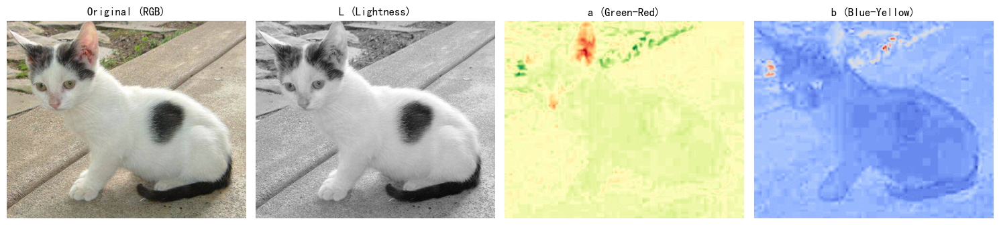

结论：Lab 感知均匀，L 与颜色分离，适合颜色校正和迁移


In [26]:
# ============ 3.5 实例：BGR -> Lab 与通道可视化 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 转 Lab：变量名叫 img_lab
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)                                  # BGR -> Lab

# 拆分通道
l, a, b = cv2.split(img_lab)                                                        # 拆分

print('Lab 图像形状:', img_lab.shape)                                               # 打印形状
print('L 范围:', l.min(), '~', l.max())                                             # 打印 L 范围
print('a 范围:', a.min(), '~', a.max())                                             # 打印 a 范围
print('b 范围:', b.min(), '~', b.max())                                             # 打印 b 范围

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original (RGB)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # L 通道
plt.imshow(l, cmap='gray')                                                          # 显示
plt.title('L (Lightness)')                                                          # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # a 通道
plt.imshow(a, cmap='RdYlGn_r')                                                      # 显示
plt.title('a (Green-Red)')                                                          # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # b 通道
plt.imshow(b, cmap='coolwarm')                                                      # 显示
plt.title('b (Blue-Yellow)')                                                        # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：Lab 感知均匀，L 与颜色分离，适合颜色校正和迁移')                       # 打印结论

---
## 3.6 色彩空间选型

| 色彩空间 | 适用场景 | 优点 | 缺点 |
|----------|----------|------|------|
| BGR / RGB | 显示、读写 | 直观 | 颜色与亮度耦合 |
| Gray | 灰度处理、边缘检测 | 快 | 丢失颜色信息 |
| HSV | 颜色分割 | H 与亮度无关 | H 是环形的，红色跨两端 |
| YCrCb | 肤色检测、视频编码 | 肤色范围稳定 | 色度分辨率低 |
| Lab | 颜色校正、颜色迁移 | 感知均匀 | 计算稍复杂 |

**选型原则**：

- **颜色分割**：优先 HSV；
- **肤色检测**：优先 YCrCb；
- **颜色校正/迁移**：优先 Lab；
- **视频编码**：YCrCb；
- **显示**：BGR 或 RGB。

---
## 3.7 颜色范围选取（inRange）

### 3.7.1 inRange 的语义：它不识别色彩空间

这是本节最容易误解的一点，先说清楚：

`cv2.inRange(src, lowerb, upperb)` 对 `src` **逐通道**做数值区间判断，返回 8 位掩码：

- 对每个像素的每个通道，判断是否满足 `lowerb[c] <= src[y, x, c] <= upperb[c]`；
- 所有通道**同时**满足 → 掩码该位置写 `255`；
- 否则 → 写 `0`。

**关键点**：`cv2.inRange` **不识别色彩空间**，它解决的是「怎么按颜色把目标从图像里挑出来」这个问题。它不知道你传进来的是 BGR、HSV、YCrCb 还是 Lab，它只做数值比较。你传什么空间的图像，`lowerb` / `upperb` 就要按那个空间的通道含义来给。

### 3.7.2 通用形式与四种空间的对照

**通用形式**（`src` 是任意多通道图像，`lowerb` / `upperb` 长度必须与 `src` 的通道数一致）：

```python
mask = cv2.inRange(src, lowerb, upperb)
```

**四种空间都成立**，只是区间含义不同：

```python
# 传 HSV 图像：区间依次是 (H, S, V)
mask = cv2.inRange(img_hsv, np.array([0, 50, 50]), np.array([10, 255, 255]))

# 传 YCrCb 图像：区间依次是 (Y, Cr, Cb)
mask = cv2.inRange(img_ycrcb, np.array([0, 133, 77]), np.array([255, 173, 127]))

# 传 Lab 图像：区间依次是 (L, a, b)
mask = cv2.inRange(img_lab, np.array([0, 128, 128]), np.array([255, 255, 255]))

# 传灰度图：区间是单通道的亮度，lowerb / upperb 是标量
mask = cv2.inRange(img_gray, 100, 200)
```

**为什么例子里常用 HSV**：因为 HSV 里 H 单独表示色相、与亮度无关，颜色分割效果最好。**这不是 `inRange` 的要求，只是 HSV 更适合颜色分割。**

### 3.7.3 注意事项

- `lowerb` 和 `upperb` 是元组、列表或 NumPy 数组，长度必须与 `src` 的通道数一致；
- 对于 HSV，H 的范围是 0~179，不是 0~360；
- 红色跨越 0 和 179 两端，需要两段 `inRange` 再合并；
- 传灰度图时，`lowerb` / `upperb` 是标量，不是元组；
- **不要用 `h_min, s_min, v_min` 这类命名给区间变量**，它们会暗示「区间必须是 H、S、V」。统一用 `lowerb` / `upperb` 更准确。

### 3.7.4 变量名约定

本章统一用 `img_hsv`、`img_ycrcb`、`img_lab` 来表示对应色彩空间的图像，不要写成 `hsv`、`ycrcb`、`lab`。原因是：

- `hsv`、`ycrcb`、`lab` 本身就是**色彩空间的专业术语**，直接当变量名会让读者分不清「这是在说空间，还是在说某个数组」；
- `img_hsv` 一眼就能看出「这是一张 HSV 空间的图像数组」，语义清晰。

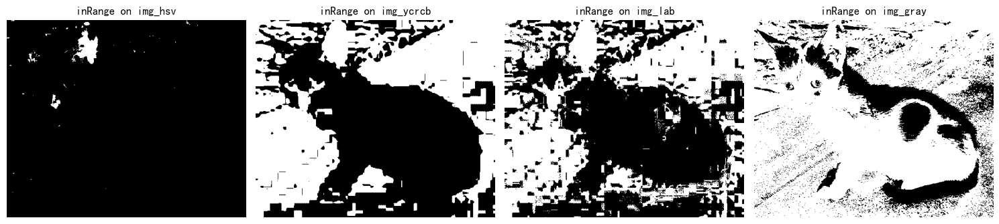

结论：
  inRange 不识别色彩空间，四种空间都成立
  区间含义由 src 所在空间决定，不是由函数决定


In [27]:
# ============ 3.7 实例一：inRange 在四种空间中都成立 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 转四种空间
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)                                  # BGR -> HSV
img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)                              # BGR -> YCrCb
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2Lab)                                  # BGR -> Lab
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)                                # BGR -> Gray

# 同一个 inRange，四种空间都成立，只是区间含义不同
lowerb_hsv = np.array([0, 50, 50])                                                  # HSV 下界 (H, S, V)
upperb_hsv = np.array([10, 255, 255])                                               # HSV 上界 (H, S, V)
mask_hsv = cv2.inRange(img_hsv, lowerb_hsv, upperb_hsv)                             # HSV 掩码

lowerb_ycrcb = np.array([0, 133, 77])                                               # YCrCb 下界 (Y, Cr, Cb)
upperb_ycrcb = np.array([255, 173, 127])                                            # YCrCb 上界 (Y, Cr, Cb)
mask_ycrcb = cv2.inRange(img_ycrcb, lowerb_ycrcb, upperb_ycrcb)                     # YCrCb 掩码

lowerb_lab = np.array([0, 128, 128])                                                # Lab 下界 (L, a, b)
upperb_lab = np.array([255, 255, 255])                                              # Lab 上界 (L, a, b)
mask_lab = cv2.inRange(img_lab, lowerb_lab, upperb_lab)                             # Lab 掩码

lowerb_gray = 100                                                                   # 灰度下界
upperb_gray = 200                                                                   # 灰度上界
mask_gray = cv2.inRange(img_gray, lowerb_gray, upperb_gray)                         # 灰度掩码

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # HSV
plt.imshow(mask_hsv, cmap='gray')                                                   # 显示
plt.title('inRange on img_hsv')                                                     # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # YCrCb
plt.imshow(mask_ycrcb, cmap='gray')                                                 # 显示
plt.title('inRange on img_ycrcb')                                                   # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # Lab
plt.imshow(mask_lab, cmap='gray')                                                   # 显示
plt.title('inRange on img_lab')                                                     # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # Gray
plt.imshow(mask_gray, cmap='gray')                                                  # 显示
plt.title('inRange on img_gray')                                                    # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：')                                                                     # 打印结论
print('  inRange 不识别色彩空间，四种空间都成立')                                   # 结论第一行
print('  区间含义由 src 所在空间决定，不是由函数决定')                              # 结论第二行

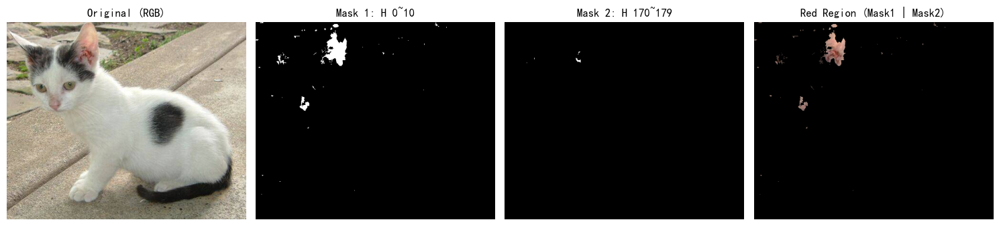

结论：
  inRange 不识别色彩空间，只对 img_hsv 逐通道做数值区间判断
  红色跨越 H 的 0 和 179 两端，必须两段 inRange 再合并


In [28]:
# ============ 3.7 实例二：用 HSV 提取红色（处理环形 H） ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 转 HSV：变量名叫 img_hsv
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)                                  # BGR -> HSV

# 红色在 H 中跨越 0 和 179 两端，所以需要两段 inRange
lowerb_1 = np.array([0, 50, 50])                                                    # 第一段下界
upperb_1 = np.array([10, 255, 255])                                                 # 第一段上界
mask1 = cv2.inRange(img_hsv, lowerb_1, upperb_1)                                    # 红色第一段

lowerb_2 = np.array([170, 50, 50])                                                  # 第二段下界
upperb_2 = np.array([179, 255, 255])                                                # 第二段上界
mask2 = cv2.inRange(img_hsv, lowerb_2, upperb_2)                                    # 红色第二段

# 合并两段
mask_red = cv2.bitwise_or(mask1, mask2)                                             # 合并掩码

# 提取红色区域
red_region = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_red)                       # 提取

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original (RGB)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # 第一段
plt.imshow(mask1, cmap='gray')                                                      # 显示
plt.title('Mask 1: H 0~10')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # 第二段
plt.imshow(mask2, cmap='gray')                                                      # 显示
plt.title('Mask 2: H 170~179')                                                      # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # 合并
plt.imshow(cv2.cvtColor(red_region, cv2.COLOR_BGR2RGB))                             # 显示
plt.title('Red Region (Mask1 | Mask2)')                                             # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：')                                                                     # 打印结论
print('  inRange 不识别色彩空间，只对 img_hsv 逐通道做数值区间判断')                  # 结论第一行
print('  红色跨越 H 的 0 和 179 两端，必须两段 inRange 再合并')                       # 结论第二行

---
## 3.8 灰度图伪彩色

人眼对**灰度的分辨力**远不如对**颜色的分辨力**。有时我们想用颜色来增强灰度图的视觉对比度——这就是**伪彩色（pseudo-color）**。

`cv2.applyColorMap(gray, colormap)`：把灰度图映射为彩色图。

**常用 colormap**：

- `COLORMAP_JET`：蓝→青→黄→红，适合热力图；
- `COLORMAP_HOT`：黑→红→黄→白，适合热成像；
- `COLORMAP_BONE`：黑→蓝→白，适合医学图像；
- `COLORMAP_RAINBOW`：彩虹色；
- `COLORMAP_VIRIDIS`：感知均匀，适合科学可视化。

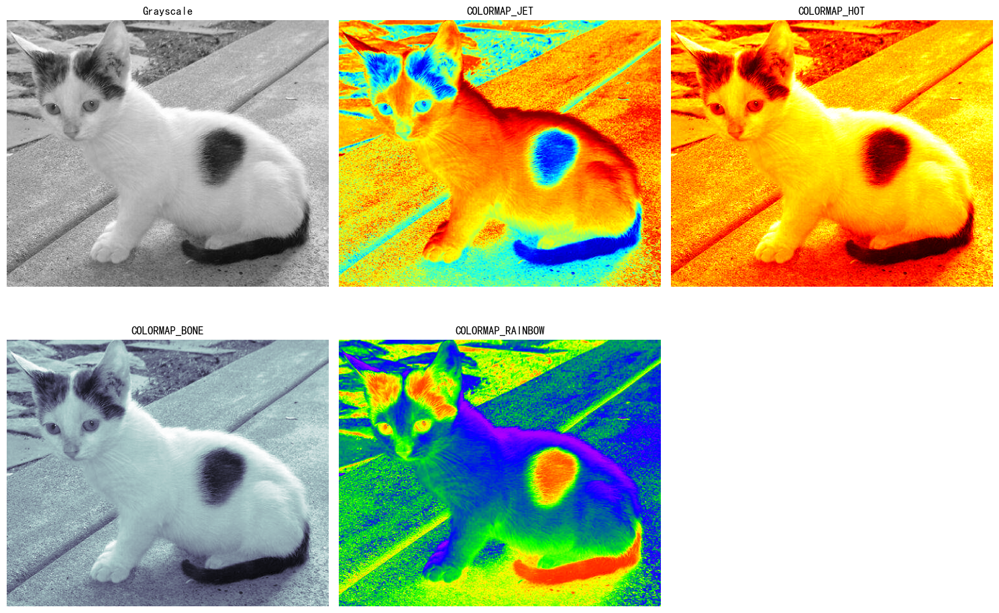

结论：伪彩色增强灰度图的视觉对比度


In [29]:
# ============ 3.8 实例：伪彩色 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 转灰度
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)                                # 灰度

# 应用不同 colormap
jet = cv2.applyColorMap(img_gray, cv2.COLORMAP_JET)                                 # JET
hot = cv2.applyColorMap(img_gray, cv2.COLORMAP_HOT)                                 # HOT
bone = cv2.applyColorMap(img_gray, cv2.COLORMAP_BONE)                               # BONE
rainbow = cv2.applyColorMap(img_gray, cv2.COLORMAP_RAINBOW)                         # RAINBOW

# 显示
plt.figure(figsize=(15, 10))                                                        # 画布

plt.subplot(2, 3, 1)                                                                # 灰度
plt.imshow(img_gray, cmap='gray')                                                   # 显示
plt.title('Grayscale')                                                              # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(2, 3, 2)                                                                # JET
plt.imshow(cv2.cvtColor(jet, cv2.COLOR_BGR2RGB))                                    # 显示
plt.title('COLORMAP_JET')                                                           # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(2, 3, 3)                                                                # HOT
plt.imshow(cv2.cvtColor(hot, cv2.COLOR_BGR2RGB))                                    # 显示
plt.title('COLORMAP_HOT')                                                           # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(2, 3, 4)                                                                # BONE
plt.imshow(cv2.cvtColor(bone, cv2.COLOR_BGR2RGB))                                   # 显示
plt.title('COLORMAP_BONE')                                                          # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(2, 3, 5)                                                                # RAINBOW
plt.imshow(cv2.cvtColor(rainbow, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('COLORMAP_RAINBOW')                                                       # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：伪彩色增强灰度图的视觉对比度')                                          # 打印结论

---
## 3.9 伪彩色图像合成

**多模态（multi-modal）数据合成伪彩色图像**：把不同来源的灰度图分别映射到 R、G、B 通道，合成为一张彩色图。

典型应用：

- 医学图像：CT、MRI、PET 融合；
- 遥感图像：不同波段合成假彩色；
- 多传感器融合：红外 + 可见光。

**做法**：

```python
b, g, r = gray1, gray2, gray3
merged = cv2.merge([b, g, r])
```

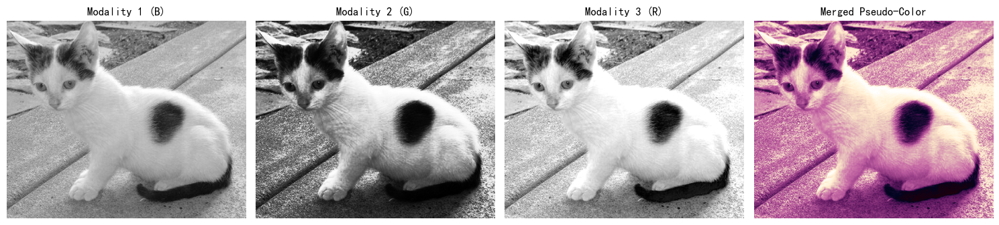

结论：多模态数据合成伪彩色，便于融合观察


In [30]:
# ============ 3.9 实例：多模态伪彩色合成 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 转灰度
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)                                # 灰度

# 模拟三种模态：不同对比度/亮度
mod1 = cv2.normalize(img_gray, None, 0, 255, cv2.NORM_MINMAX)                       # 模态1
mod2 = cv2.equalizeHist(img_gray)                                                   # 模态2（直方图均衡）
mod3 = cv2.convertScaleAbs(img_gray, alpha=1.5, beta=-50)                           # 模态3（对比度拉伸）

# 合成伪彩色：B=mod1, G=mod2, R=mod3
merged = cv2.merge([mod1, mod2, mod3])                                              # 合成

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 模态1
plt.imshow(mod1, cmap='gray')                                                       # 显示
plt.title('Modality 1 (B)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # 模态2
plt.imshow(mod2, cmap='gray')                                                       # 显示
plt.title('Modality 2 (G)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # 模态3
plt.imshow(mod3, cmap='gray')                                                       # 显示
plt.title('Modality 3 (R)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # 合成
plt.imshow(cv2.cvtColor(merged, cv2.COLOR_BGR2RGB))                                 # 显示
plt.title('Merged Pseudo-Color')                                                    # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：多模态数据合成伪彩色，便于融合观察')                                    # 打印结论

---
## 3.10 色彩风格滤镜与调节

**色彩风格滤镜（color style filter）**：通过调整 HSV 中的 H、S、V 来改变图像的整体色调。

- **H 偏移**：改变色相（比如把红色变成蓝色）；
- **S 缩放**：改变饱和度（比如让颜色更鲜艳或更灰）；
- **V 缩放**：改变明度（比如让图像更亮或更暗）。

**实现**：转 HSV → 调整通道 → 转回 BGR。

**注意**：

- H 是环形的，偏移后要取模 180；
- S 和 V 要截断到 0~255。

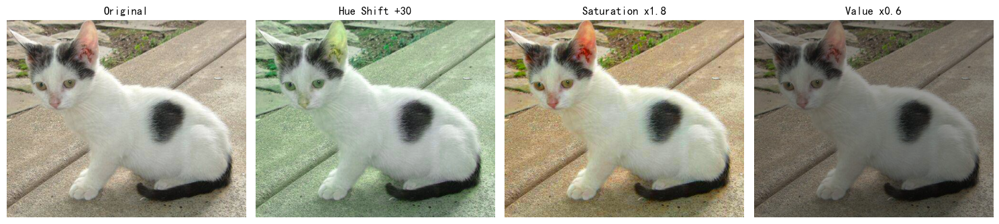

结论：通过 HSV 调节可实现色彩风格滤镜


In [31]:
# ============ 3.10 实例：HSV 调节实现色彩风格 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 转 HSV：变量名叫 img_hsv
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)               # BGR -> HSV
h, s, v = cv2.split(img_hsv)                                                        # 拆分

# 风格 1：色相偏移
h_shift = (h + 30) % 180                                                            # H 偏移 30
hsv_shift = cv2.merge([h_shift, s, v])                                              # 合并
img_shift = cv2.cvtColor(hsv_shift.astype(np.uint8), cv2.COLOR_HSV2BGR)             # HSV -> BGR

# 风格 2：提高饱和度
s_boost = np.clip(s * 1.8, 0, 255)                                                  # S 放大 1.8 倍
hsv_boost = cv2.merge([h, s_boost, v])                                              # 合并
img_boost = cv2.cvtColor(hsv_boost.astype(np.uint8), cv2.COLOR_HSV2BGR)             # HSV -> BGR

# 风格 3：降低明度
v_dark = np.clip(v * 0.6, 0, 255)                                                   # V 缩小 0.6 倍
hsv_dark = cv2.merge([h, s, v_dark])                                                # 合并
img_dark = cv2.cvtColor(hsv_dark.astype(np.uint8), cv2.COLOR_HSV2BGR)               # HSV -> BGR

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original')                                                               # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # 色相偏移
plt.imshow(cv2.cvtColor(img_shift, cv2.COLOR_BGR2RGB))                              # 显示
plt.title('Hue Shift +30')                                                          # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # 饱和度增强
plt.imshow(cv2.cvtColor(img_boost, cv2.COLOR_BGR2RGB))                              # 显示
plt.title('Saturation x1.8')                                                        # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # 明度降低
plt.imshow(cv2.cvtColor(img_dark, cv2.COLOR_BGR2RGB))                               # 显示
plt.title('Value x0.6')                                                             # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：通过 HSV 调节可实现色彩风格滤镜')                                      # 打印结论

---
## 3.11 颜色分割完整流程

**颜色分割（color segmentation）完整流程**：转 HSV → `inRange` → 形态学（morphology）去噪 → 轮廓（contour）提取。

**步骤**：

1. **转 HSV**：BGR → HSV，利用 H 与亮度无关的特性；
2. **`inRange`**：根据 H/S/V 范围生成掩码（注意 `inRange` 不识别色彩空间，区间含义由 `img_hsv` 的通道决定）；
3. **形态学去噪**：开运算去小噪点，闭运算填小孔；
4. **轮廓提取**：`findContours` 找到目标轮廓。

**应用**：车牌识别、红绿灯检测、水果分拣。

找到 1 个轮廓


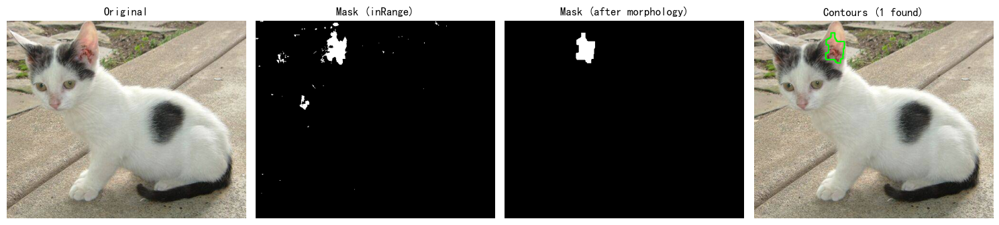

结论：完整颜色分割流程：HSV -> inRange -> 形态学 -> 轮廓


In [32]:
# ============ 3.11 实例：颜色分割完整流程 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 1. 转 HSV
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)                                  # BGR -> HSV

# 2. inRange（提取红色）：用 lowerb/upperb 命名，避免暗示 H/S/V
lowerb_1 = np.array([0, 50, 50])                                                    # 第一段下界
upperb_1 = np.array([10, 255, 255])                                                 # 第一段上界
mask1 = cv2.inRange(img_hsv, lowerb_1, upperb_1)                                    # 红色第一段

lowerb_2 = np.array([170, 50, 50])                                                  # 第二段下界
upperb_2 = np.array([179, 255, 255])                                                # 第二段上界
mask2 = cv2.inRange(img_hsv, lowerb_2, upperb_2)                                    # 红色第二段

mask = cv2.bitwise_or(mask1, mask2)                                                 # 合并

# 3. 形态学去噪
kernel = np.ones((5, 5), np.uint8)                                                  # 5x5 核
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)           # 开运算
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=2)    # 闭运算

# 4. 轮廓提取
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # 找轮廓

# 在图上标记轮廓
img_marked = img_bgr.copy()                                                         # 拷贝
cv2.drawContours(img_marked, contours, -1, (0, 255, 0), 2)                         # 画轮廓

print(f'找到 {len(contours)} 个轮廓')                                               # 打印轮廓数

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original')                                                               # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # 初始掩码
plt.imshow(mask, cmap='gray')                                                       # 显示
plt.title('Mask (inRange)')                                                         # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # 去噪后掩码
plt.imshow(mask_clean, cmap='gray')                                                 # 显示
plt.title('Mask (after morphology)')                                                # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # 轮廓
plt.imshow(cv2.cvtColor(img_marked, cv2.COLOR_BGR2RGB))                             # 显示
plt.title(f'Contours ({len(contours)} found)')                                      # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：完整颜色分割流程：HSV -> inRange -> 形态学 -> 轮廓')                   # 打印结论

---
## 3.12 肤色检测

**肤色检测**：在图像中逐像素判断“是否属于人体皮肤”，输出一张二值掩码（255=肤色，0=非肤色），再据此提取肤色区域或做后续处理（人脸检测、手势识别、美颜等）。

**为什么能检测**：肤色在 YCrCb 的 Cr/Cb 色度平面上分布集中，且与亮度 Y 基本无关，因此可以用固定阈值圈出肤色范围。

**局限**：光照、白平衡、人种差异、背景中颜色相近的物体会影响精度；经典阈值法只能给出“像肤色”的区域，不能识别具体部位。

> **示例图说明**：本节检测的是**人体皮肤**，所以示例图用同文件夹下的 `imgLena.tif`（含人脸和肩部皮肤），而不是 `P&V/cat.jpg`（猫图里通常没有人体皮肤，无法演示肤色检测）。

**肤色检测（skin detection）完整流程**：YCrCb + 形态学。

**步骤**：

1. **转 YCrCb**：Y 是亮度，Cr/Cb 是色度；
2. **`inRange`**：使用经典肤色阈值 `133 < Cr < 173, 77 < Cb < 127`（再次提醒：`inRange` 不识别色彩空间，这里的区间是对 `img_ycrcb` 的三个通道而言）；
3. **形态学**：开运算去噪，闭运算填孔；
4. **轮廓提取**：找到肤色区域。

**应用**：人脸检测、手势识别、美颜。

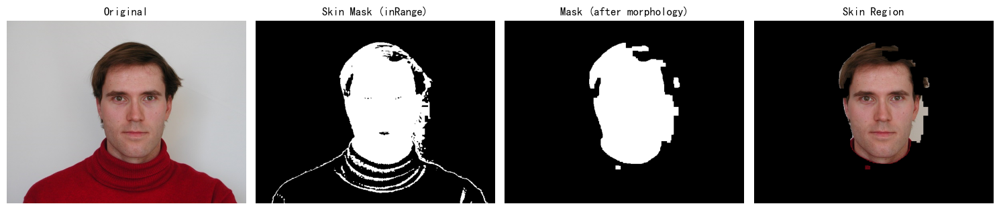

结论：YCrCb + 形态学是肤色检测的经典流程


In [ ]:
# ============ 3.12 实例：肤色检测完整流程 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/man.jpg')                                                   # 读取含人体皮肤的测试图
assert img_bgr is not None, '图像读取失败，请检查路径:P&V/man.jpg'                 # 断言图像读取成功

# 1. 转 YCrCb
img_ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)                              # BGR -> YCrCb

# 2. 肤色阈值：用 lowerb/upperb 命名
lowerb = np.array([0, 133, 77])                                                     # 下界 (Y, Cr, Cb)
upperb = np.array([255, 173, 127])                                                  # 上界 (Y, Cr, Cb)
skin_mask = cv2.inRange(img_ycrcb, lowerb, upperb)                                  # 肤色掩码

# 3. 形态学去噪
kernel = np.ones((5, 5), np.uint8)                                                  # 5x5 核
skin_clean = cv2.morphologyEx(skin_mask, cv2.MORPH_OPEN, kernel, iterations=2)      # 开运算
skin_clean = cv2.morphologyEx(skin_clean, cv2.MORPH_CLOSE, kernel, iterations=2)    # 闭运算

# 4. 提取肤色区域
skin = cv2.bitwise_and(img_bgr, img_bgr, mask=skin_clean)                           # 提取

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 4, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original')                                                               # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 2)                                                                # 初始掩码
plt.imshow(skin_mask, cmap='gray')                                                  # 显示
plt.title('Skin Mask (inRange)')                                                    # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 3)                                                                # 去噪后
plt.imshow(skin_clean, cmap='gray')                                                 # 显示
plt.title('Mask (after morphology)')                                                # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 4, 4)                                                                # 肤色区域
plt.imshow(cv2.cvtColor(skin, cv2.COLOR_BGR2RGB))                                   # 显示
plt.title('Skin Region')                                                            # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：YCrCb + 形态学是肤色检测的经典流程')                                    # 打印结论

---
## 3.13 白平衡基础

**白平衡（white balance）**：消除光源颜色对图像的影响，使白色物体在图像中呈现白色。

**为什么需要白平衡**：不同光源（日光、白炽灯、荧光灯）的色温不同，导致同一物体在不同光源下颜色不同。白平衡就是校正这种偏差。

### 算法怎么知道哪一块是白色？

这是白平衡的核心难点：**算法通常不知道哪一块是白色**，它靠的是**假设（先验）**，而不是识别。不同的白平衡算法，本质上是不同的“白色假设”。

- **灰度世界**：假设整幅图像的平均颜色是灰色（R、G、B 均值相等）。它不看哪一块是白色，只看全图统计量。如果画面本身就以红色为主（如一大片红花、夕阳），这个假设就崩了——算法会把红花“校”成灰色。
- **完美反射**：假设图像中**最亮的那个点**（或最亮的 1%~5% 像素）就是白色。它用这个“最亮点”去缩放各通道。如果最亮点不是白色，而是高光、反光、白云、灯光，就会偏色；如果画面里根本没有白色，也会错。
- **灰卡 / 白卡（工程做法）**：真正严谨的场景（摄影、工业颜色检测）**不靠算法猜**，而是在画面里放一块已知的灰卡或白卡，告诉算法“这块就是标准白”。这是最可靠的做法——**白色是由人指定的，不是算法猜的**。

所以：**传统白平衡算法并不“认识”白色**，它只是用某个假设来反推光源颜色，再据此校正。白平衡失败，往往不是算法坏了，而是**假设不成立**。

**三种经典方法**：

1. **灰度世界（gray world）**：假设图像的平均颜色是灰色，分别缩放 R、G、B 通道使均值相等；
2. **完美反射（perfect reflector）**：假设图像中最亮的点是白色，用该点缩放各通道；
3. **Reinhard 颜色迁移**：把源图的颜色分布迁移到目标图。

**公式**（灰度世界）：

$$
R' = R \cdot \frac{\bar{G}}{\bar{R}}, \quad
B' = B \cdot \frac{\bar{G}}{\bar{B}}
$$

其中 $\bar{R}, \bar{G}, \bar{B}$ 是各通道均值。

原始均值: B=144.3, G=159.9, R=165.9
白平衡后均值: B=156.5, G=156.7, R=156.7


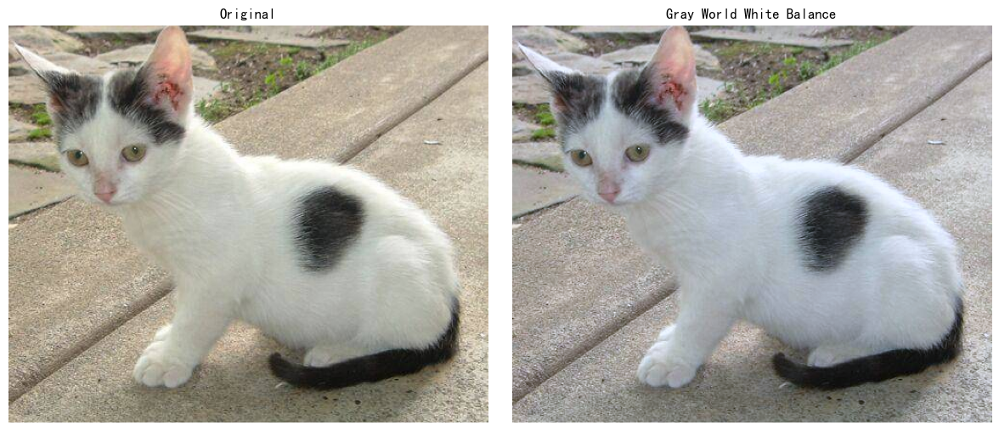

结论：灰度世界白平衡使各通道均值相等
注意：它假设全图平均是灰色，画面主色调单一时假设不成立


In [ ]:
# ============ 3.13 实例：灰度世界白平衡 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 灰度世界白平衡
b, g, r = cv2.split(img_bgr.astype(np.float32))                                     # 拆分并转 float
b_avg, g_avg, r_avg = b.mean(), g.mean(), r.mean()                                  # 各通道均值
gray_avg = (b_avg + g_avg + r_avg) / 3                                              # 总均值

b_balanced = np.clip(b * (gray_avg / b_avg), 0, 255)                                # 缩放 B
g_balanced = np.clip(g * (gray_avg / g_avg), 0, 255)                                # 缩放 G
r_balanced = np.clip(r * (gray_avg / r_avg), 0, 255)                                # 缩放 R

balanced = cv2.merge([b_balanced, g_balanced, r_balanced]).astype(np.uint8)         # 合并

print(f'原始均值: B={b_avg:.1f}, G={g_avg:.1f}, R={r_avg:.1f}')                    # 打印原始均值
print(f'白平衡后均值: B={b_balanced.mean():.1f}, G={g_balanced.mean():.1f}, R={r_balanced.mean():.1f}')  # 打印白平衡后

# 显示
plt.figure(figsize=(12, 5))                                                         # 画布

plt.subplot(1, 2, 1)                                                                # 原图
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))                                # 显示
plt.title('Original')                                                               # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 2, 2)                                                                # 白平衡后
plt.imshow(cv2.cvtColor(balanced, cv2.COLOR_BGR2RGB))                               # 显示
plt.title('Gray World White Balance')                                               # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：灰度世界白平衡使各通道均值相等')                                        # 打印结论
print('注意：它假设全图平均是灰色，画面主色调单一时假设不成立')                      # 提醒

---
## 3.14 颜色迁移基础（Reinhard 方法）

**颜色迁移（color transfer）**：把一张图（源图）的颜色风格迁移到另一张图（目标图）。

**Reinhard 方法**：在 Lab 空间中，对每个通道做**均值-标准差匹配**：

$$
L_{target}' = \frac{\sigma_{target}}{\sigma_{source}} \cdot (L_{source} - \mu_{source}) + \mu_{target}
$$

其中 $\mu$ 是均值，$\sigma$ 是标准差。

**步骤**：

1. 转 Lab；
2. 计算源图和目标图的均值和标准差；
3. 对源图每个通道做上述变换；
4. 转回 BGR。

**应用**：风格迁移、图像增强、颜色校正。

In [ ]:
# ============ 3.14 实例：Reinhard 颜色迁移 ============
# 本节完全独立：自己导入库、自己读取图像

import numpy as np                                                                  # 导入 NumPy
import cv2                                                                          # 导入 OpenCV
import matplotlib.pyplot as plt                                                     # 导入 Matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False                                          # 正常显示负号

img_bgr = cv2.imread('P&V/cat.jpg')                                                 # 读取 BGR 图像
assert img_bgr is not None, '图像读取失败，请检查路径: P&V/cat.jpg'                 # 断言图像读取成功

# 用同一张图模拟源图和目标图（实际使用时应是两张不同图）
source = img_bgr.copy()                                                             # 源图
target = cv2.convertScaleAbs(img_bgr, alpha=1.2, beta=30)                           # 目标图（模拟不同色调）

# 转 Lab
source_lab = cv2.cvtColor(source, cv2.COLOR_BGR2Lab).astype(np.float32)             # 源图 Lab
target_lab = cv2.cvtColor(target, cv2.COLOR_BGR2Lab).astype(np.float32)             # 目标图 Lab

# 计算均值和标准差
s_mean, s_std = source_lab.mean(axis=(0, 1)), source_lab.std(axis=(0, 1))           # 源图统计
t_mean, t_std = target_lab.mean(axis=(0, 1)), target_lab.std(axis=(0, 1))           # 目标图统计

print('源图均值:', s_mean)                                                          # 打印源图均值
print('目标图均值:', t_mean)                                                        # 打印目标图均值

# 均值-标准差匹配
migrated_lab = (source_lab - s_mean) / (s_std + 1e-6) * t_std + t_mean              # 迁移
migrated_lab = np.clip(migrated_lab, 0, 255).astype(np.uint8)                       # 截断

# 转回 BGR
migrated = cv2.cvtColor(migrated_lab, cv2.COLOR_Lab2BGR)                            # Lab -> BGR

# 显示
plt.figure(figsize=(15, 5))                                                         # 画布

plt.subplot(1, 3, 1)                                                                # 源图
plt.imshow(cv2.cvtColor(source, cv2.COLOR_BGR2RGB))                                 # 显示
plt.title('Source')                                                                 # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 3, 2)                                                                # 目标图
plt.imshow(cv2.cvtColor(target, cv2.COLOR_BGR2RGB))                                 # 显示
plt.title('Target (Reference)')                                                     # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.subplot(1, 3, 3)                                                                # 迁移后
plt.imshow(cv2.cvtColor(migrated, cv2.COLOR_BGR2RGB))                               # 显示
plt.title('Migrated (Reinhard)')                                                    # 标题
plt.axis('off')                                                                     # 关闭坐标轴

plt.tight_layout()                                                                  # 调整间距
plt.show()                                                                          # 渲染

print('结论：Reinhard 方法在 Lab 空间做均值-标准差匹配实现颜色迁移')                # 打印结论

---
## 3.15 常见坑

| 问题 | 原因 | 解决 |
|------|------|------|
| 红蓝互换 | BGR 直接显示 | 用 `cvtColor` 转 RGB |
| 颜色分割不准 | 用了 RGB 而非 HSV | 转 HSV 后再分割 |
| 红色分割不全 | H 跨 0/179 | 两段 `inRange` 再合并 |
| `HSV_FULL` 阈值不对 | 范围变了 | 用 `HSV_FULL` 自己的阈值 |
| 肤色检测不准 | 光照变化 | 用 YCrCb，Cr/Cb 范围较稳 |
| 用猫图做肤色检测 | 猫图里没有人体皮肤 | 用含人体皮肤的图（如 `imgLena.tif`） |
| `inRange` 结果全黑 | 阈值范围不对 | 先查看目标空间的取值范围 |
| 颜色迁移后偏色 | 未截断 | `np.clip` 到 0~255 |
| 白平衡后过曝 | 缩放系数过大 | 用 `np.clip` 截断 |
| 白平衡后颜色更怪 | 假设不成立（如全图以红色为主） | 换用完美反射或放灰卡 |
| HSV 转 Lab 报错 | 不能直接转 | 必须先转回 BGR |
| 形态学后物体消失 | 腐蚀太多 | 减少 `iterations` |
| 轮廓提取为空 | 掩码全黑 | 检查 `inRange` 阈值 |
| 把 `img_hsv` 当成特殊类型 | 误以为变量名=色彩空间 | `img_hsv` 只是普通 NumPy 数组 |
| 以为 `inRange` 只适用于 HSV | 语义误解 | `inRange` 不识别色彩空间，四种空间都成立 |

---
## 3.16 小结

- **BGR / RGB**：OpenCV 默认 BGR，Matplotlib 期望 RGB，直接显示会红蓝互换；
- **BGR ↔ 灰度**：加权公式 `Y = 0.299R + 0.587G + 0.114B`；
- **HSV**：H ∈ [0, 179]，S/V ∈ [0, 255]；H 是环形的，红色跨 0 和 179；适合颜色分割；
- **HSV 公式**：V = Cmax，S = Δ/Cmax，H 按最大通道分三段计算（见 3.3.2）；
- **HSV_FULL**：H ∈ [0, 255]，精度更高，但阈值范围不同；
- **YCrCb**：Y 亮度 + Cr/Cb 色度；经典肤色阈值 `133 < Cr < 173, 77 < Cb < 127`；
- **YCrCb 公式**：Y = 0.299R+0.587G+0.114B，Cr = (R-Y)×0.713+0.5，Cb = (B-Y)×0.564+0.5（见 3.4.1）；
- **Lab**：感知均匀，L 亮度 + a 绿红 + b 蓝黄；适合颜色校正和迁移；
- **Lab 公式**：需经 XYZ 中间空间，含伽马校正和分段函数（见 3.5.1）；
- **色彩空间选型**：分割用 HSV，肤色用 YCrCb，校正/迁移用 Lab；
- **`inRange`**：**不识别色彩空间**，只对 `src` 逐通道做数值区间判断；四种空间都成立；红色需两段；
- **术语与变量名**：`HSV` / `YCrCb` / `Lab` 是色彩空间术语，代码中变量统一用 `img_hsv` / `img_ycrcb` / `img_lab`；
- **伪彩色**：`applyColorMap` 增强灰度图对比度；
- **多模态合成**：不同模态映射到 R/G/B 通道；
- **色彩风格滤镜**：HSV 中 H 偏移、S 缩放、V 缩放；
- **颜色分割完整流程**：HSV → `inRange` → 形态学 → 轮廓；
- **肤色检测完整流程**：YCrCb + 形态学；检测对象是**人体皮肤**，示例图用 `imgLena.tif`；
- **白平衡**：灰度世界、完美反射；**算法并不识别白色，靠假设**——灰度世界假设全图平均是灰，完美反射假设最亮点是白，严谨场景用灰卡/白卡；假设不成立时白平衡会失败；
- **颜色迁移**：Reinhard 方法，Lab 空间均值-标准差匹配。

**核心原则**：

1. 每一处讲解都配可运行代码，每一段代码都显示结果；
2. 每个代码块都**完全自包含**——自己导入库、自己读取图像（或自建测试数据），不依赖其他任何小节；
3. 这样做的好处是：你可以在任意小节单独运行代码，也方便复习某一节时不用从头跑一遍；
4. **变量名与术语分离**：色彩空间术语（HSV、YCrCb、Lab）不与变量名混用，图像数组统一用 `img_xxx` 前缀；
5. **`inRange` 不绑定任何色彩空间**：先讲通用语义，再给四种空间的对照例子，区间变量统一用 `lowerb` / `upperb`；
6. **示例图要与概念匹配**：肤色检测检测的是人体皮肤，示例图用 `man.jpg`，不用 `cat.jpg`。